In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

/nesi/project/niwa00018/queenle/ml_env_v2/lib/python3.8/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
processing = 'raw'

# load observations
obs_dfs = {}
for var in ['temp','precip','streamflow']:
    seasonal_dfs = []
    for season in ['winter','spring','summer','autumn']:
        df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/'+var+'/'+var+'_obs_'+season+'_'+processing+'.csv')
        seasonal_dfs.append(df)
        
    var_df = pd.concat(seasonal_dfs,axis=0)
    var_df['date'] = pd.to_datetime(var_df['date'])
    var_df = var_df.set_index('date').sort_index()
    if var == 'streamflow':
        var_df = var_df.drop('36001',axis=1)
        
    obs_dfs[var] = var_df

# load streamflow metadata
streamflow_meta_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
streamflow_meta_df.set_index('Number',inplace=True)
streamflow_meta_df = streamflow_meta_df.loc[[int(s) for s in obs_dfs['streamflow'].columns]]
streamflow_meta_df.sort_values('gauge_lat', ascending = False, inplace=True)
streamflow_meta_df['number_label'] = np.arange(1,len(streamflow_meta_df)+1)
streamflow_meta_df['number_copy'] = streamflow_meta_df.index.values.tolist()


In [4]:
obs_dfs['streamflow']

,71132,46618,64602,71135,77505,16501,1043427,71120,71129,62103,...,1043461,71123,57009,95101,65104,29224,79704,75232,64610,93203
date,,,,,,,,,,,,,,,,,,,,,
1931-12-01,96288.639344,NaN,NaN,NaN,NaN,NaN,NaN,94389.852459,NaN,NaN,...,NaN,204205.508197,NaN,NaN,NaN,NaN,355835.475410,NaN,NaN,NaN
1932-03-01,60019.956522,NaN,NaN,NaN,NaN,NaN,NaN,49395.706522,NaN,NaN,...,NaN,94597.282609,NaN,NaN,NaN,NaN,191774.086957,NaN,NaN,NaN
1932-06-01,22095.402174,NaN,NaN,NaN,NaN,NaN,NaN,24327.271739,NaN,NaN,...,NaN,32106.010870,NaN,NaN,NaN,NaN,142777.934783,NaN,NaN,NaN
1932-09-01,66399.098901,NaN,NaN,NaN,NaN,NaN,NaN,69152.989011,NaN,NaN,...,NaN,91767.439560,NaN,NaN,NaN,NaN,323635.769231,NaN,NaN,NaN
1932-12-01,133719.011111,NaN,NaN,NaN,NaN,NaN,NaN,114616.877778,NaN,NaN,...,NaN,255816.600000,NaN,NaN,NaN,NaN,315297.111111,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01,NaN,4295.600000,57341.100000,8354.000000,14495.722222,38940.688889,8291.711111,NaN,3330.822222,13441.322222,...,6035.977778,NaN,21565.577778,70480.833333,34513.600000,16060.600000,NaN,13712.222222,302.570233,169420.733333
2019-03-01,NaN,1952.173913,62849.456522,9826.586957,20431.250000,46286.695652,6251.478261,NaN,2948.923913,13547.804348,...,7557.217391,NaN,22761.869565,122758.554348,37078.913043,14580.326087,NaN,12536.358696,229.510348,379698.869565
2019-06-01,NaN,10345.097826,88507.608696,6307.989130,20872.467391,100586.456522,13190.293478,NaN,2572.630435,27099.380435,...,18877.184783,NaN,59794.184783,132343.217391,51653.163043,31492.413043,NaN,43290.326087,758.822033,515798.000000


In [8]:
# 1 create converted obs files

seasons_a = ['autumn','winter','spring','summer']
var = 'streamflow'

obs_df = obs_dfs[var]
for i,s in enumerate([3,6,9,12]):
    season_df = obs_df.loc[obs_df.index.month==s]
    
    converted_list = []
    for site in season_df:
        area_m2 = streamflow_meta_df.loc[int(site)]['area_km2']*1e6

        obs_ts = season_df[site]
        obs_ts = obs_ts / 1000 # m3/s
        obs_ts = obs_ts / area_m2 # m/s
        obs_ts = obs_ts * 1000 * 86400 # mm/day
        
        converted_list.append(obs_ts)
        
    converted_df = pd.concat(converted_list,axis=1)
    
    converted_df.to_csv(f'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/{var}/{var}_obs_{seasons_a[i]}_converted.csv')


In [3]:
var = 'streamflow'
test = pd.read_csv(f'/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/{var}/{var}_obs_winter_converted.csv')

In [12]:
# create converted model files

in_dir = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/raw/ROF/full/catchment_resolution'
out_dir = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/converted/ROF/catchment_resolution'

for scen in ['HPB','HPB_NAT']:

    print(scen)

    for s in ['winter','spring','summer','autumn']:
        print(s)

        df_list = []
        for ens_mem in range(1,101):
            #print(ens_mem)
            
            if ens_mem == 100:
                number = '100'
            else:
                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)
                
            df = pd.read_csv(f'{in_dir}/ROF_d4PDF_{scen}_m{number}_raw_{s}_1951-2021.csv')
            df = df.set_index('time').drop('Unnamed: 0',axis=1)
            
            df = df * 86400
            
            df.to_csv(f'{out_dir}/ROF_d4PDF_{scen}_m{number}_converted_{s}_1951-2021.csv')

            df_list.append(df)
        
        ens_mean_df = sum(df_list)/len(df_list)
        ens_mean_df.to_csv(f'{out_dir}/ROF_d4PDF_{scen}_ensMean_converted_{s}_1951-2021.csv')
    

"\nfor scen in ['HPB','HPB_NAT']:\n\n    print(scen)\n\n    for s in ['winter','spring','summer','autumn']:\n        print(s)\n\n        df_list = []\n        for ens_mem in range(1,101):\n            #print(ens_mem)\n            \n            if ens_mem == 100:\n                number = '100'\n            else:\n                number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)\n                \n            df = pd.read_csv(f'{in_dir}/ROF_d4PDF_{scen}_m{number}_raw_{s}_1951-2021.csv')\n            df = df.set_index('time').drop('Unnamed: 0',axis=1)\n            \n            df = df * 86400\n            \n            df.to_csv(f'{out_dir}/ROF_d4PDF_{scen}_m{number}_converted_{s}_1951-2021.csv')\n\n            df_list.append(df)\n        \n        ens_mean_df = sum(df_list)/len(df_list)\n        ens_mean_df.to_csv(f'{out_dir}/ROF_d4PDF_{scen}_ensMean_converted_{s}_1951-2021.csv')\n    "

In [103]:
'''
HAVE A LOOK AT RESULTS
'''



winter_model = pd.read_csv(f'{out_dir}/ROF_d4PDF_HPB_ensMean_converted_winter_1951-2021.csv')
winter_model = winter_model.set_index('time')['1951':'2021']

winter_obs = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/streamflow/streamflow_obs_winter_converted.csv')
winter_obs = winter_obs.set_index('date')['1951':'2021']

errors = (winter_model - winter_obs)
abs_errors = abs(errors)
mae = abs_errors.mean()

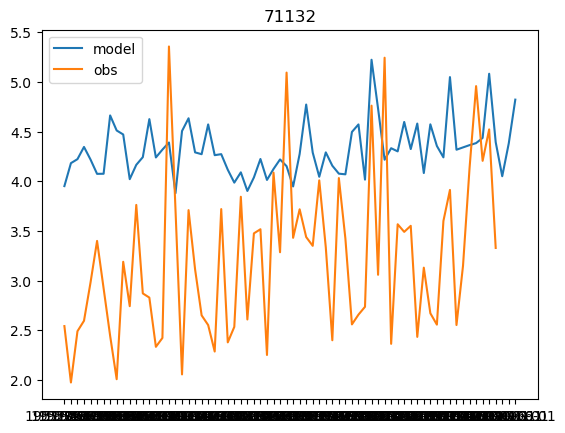

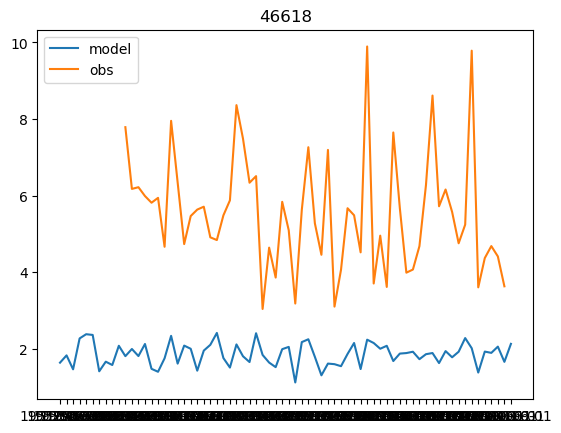

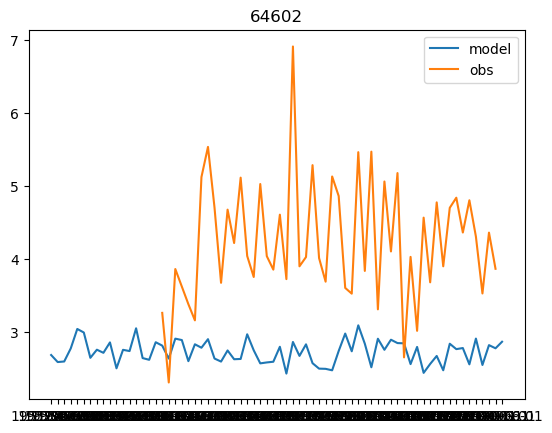

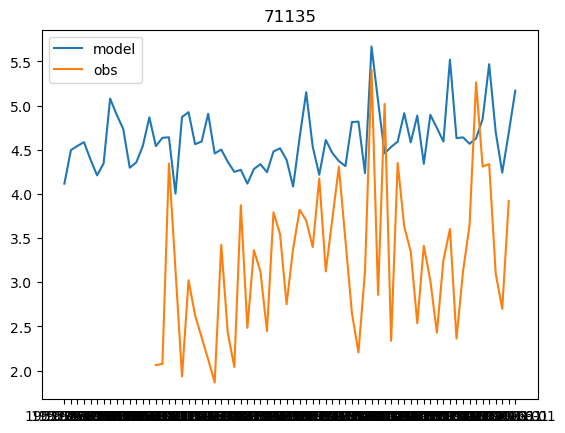

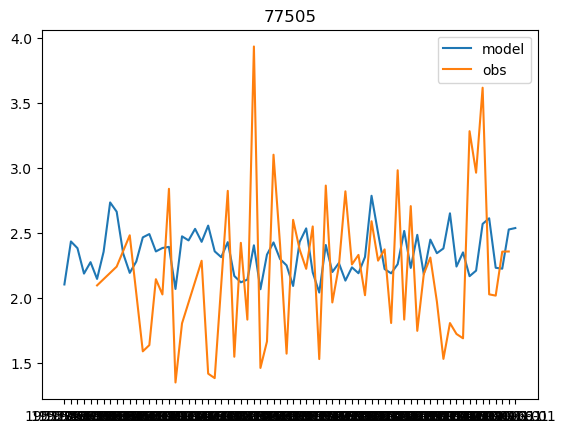

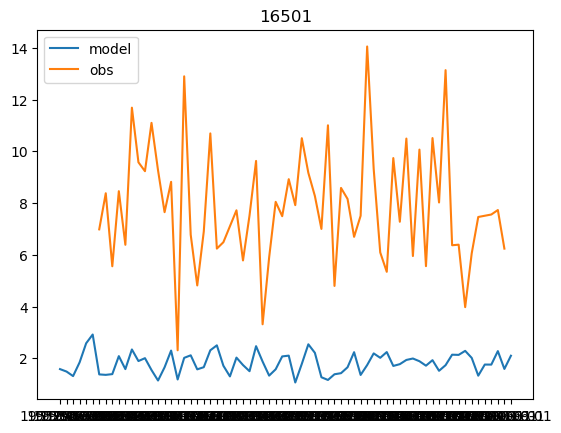

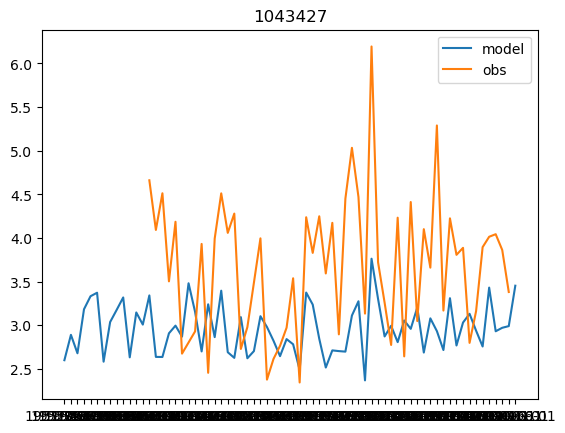

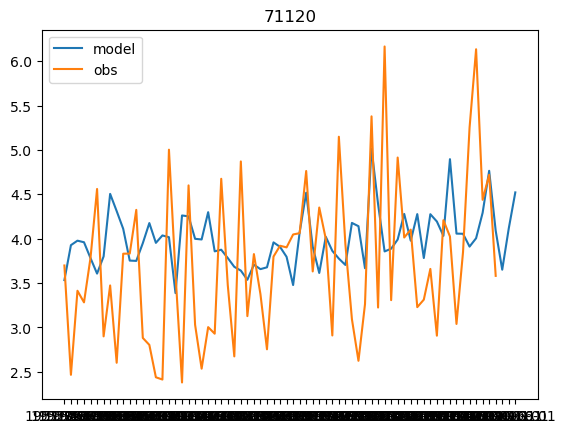

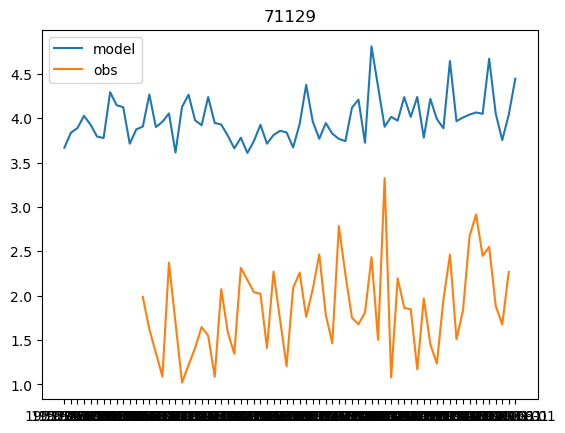

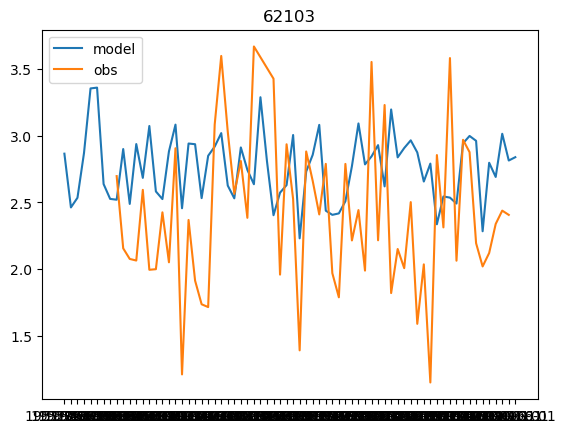

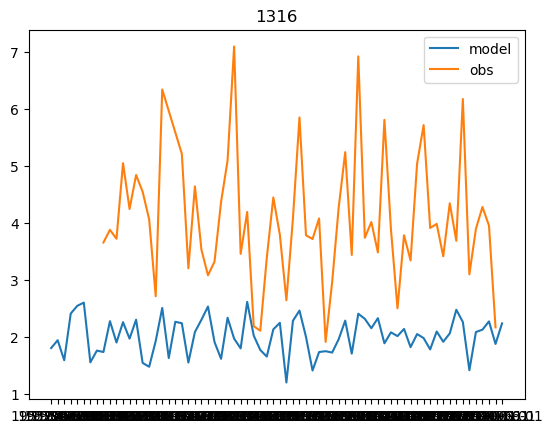

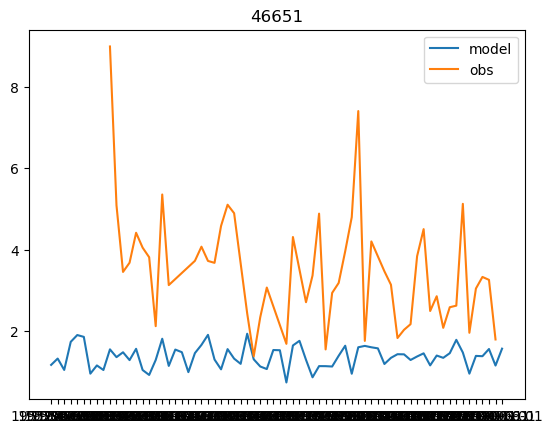

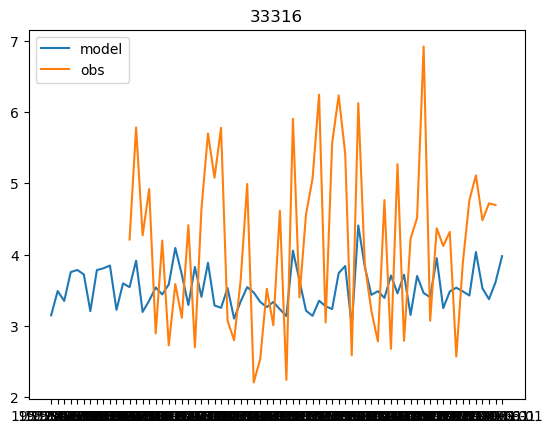

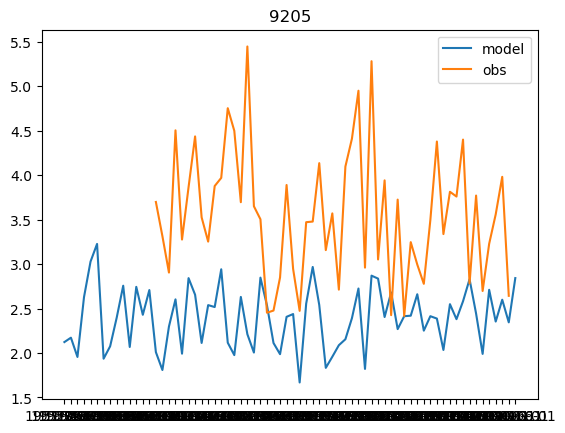

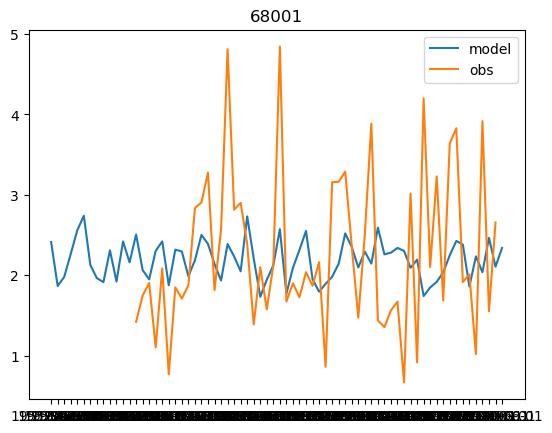

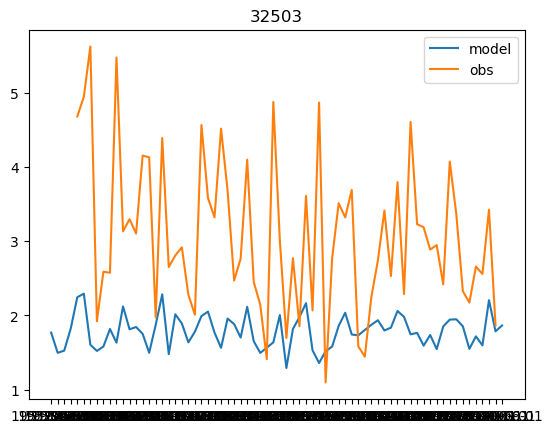

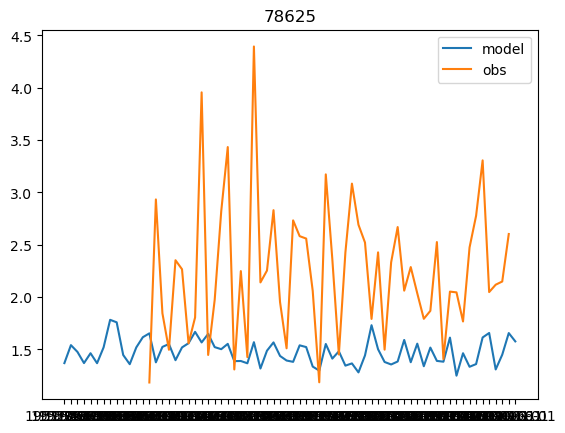

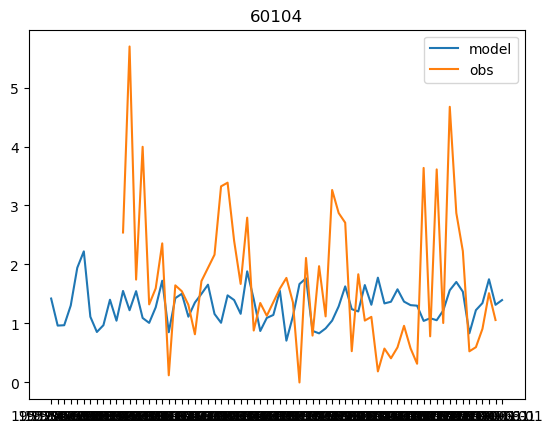

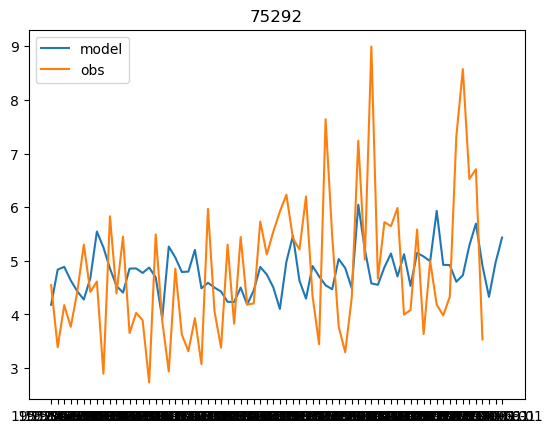

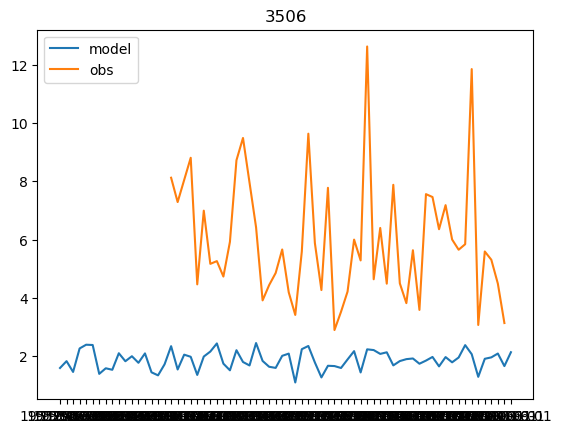

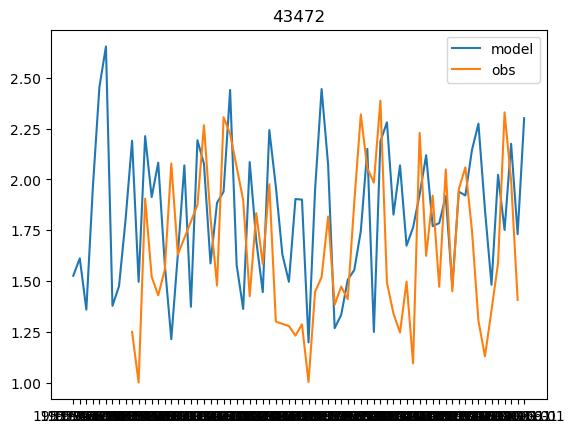

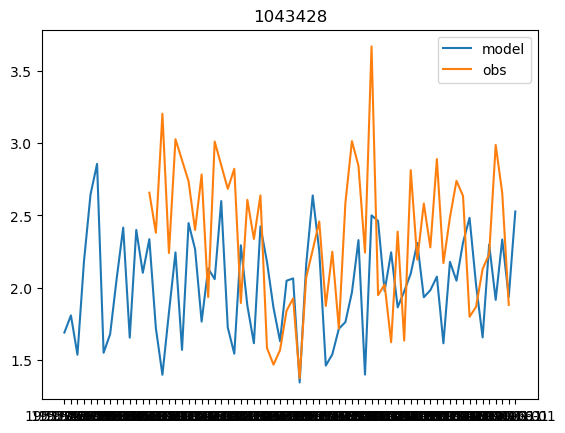

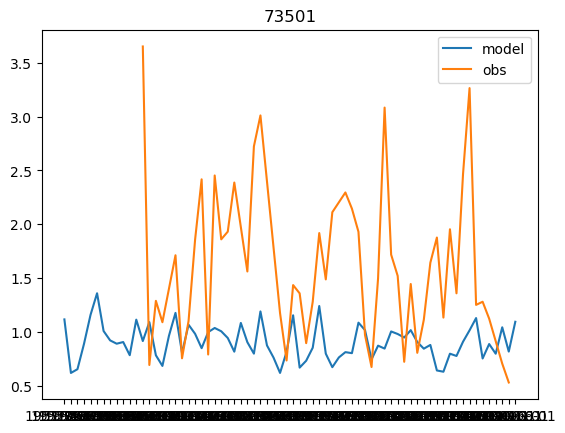

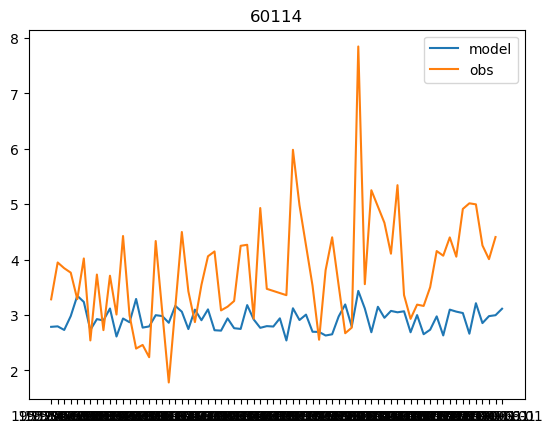

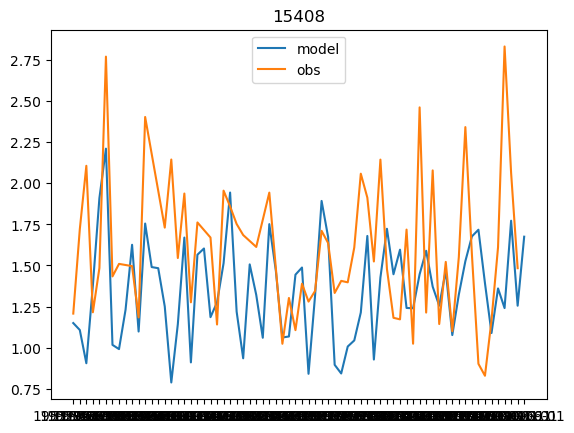

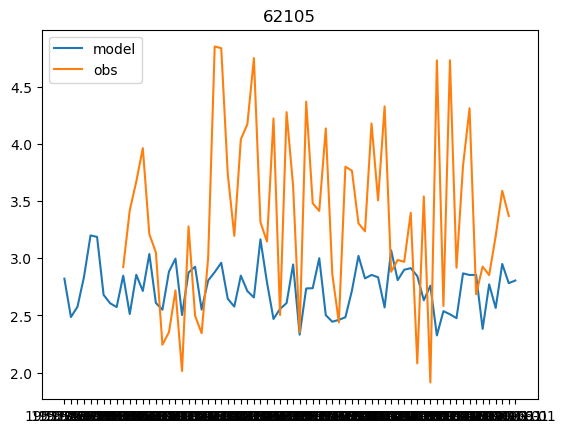

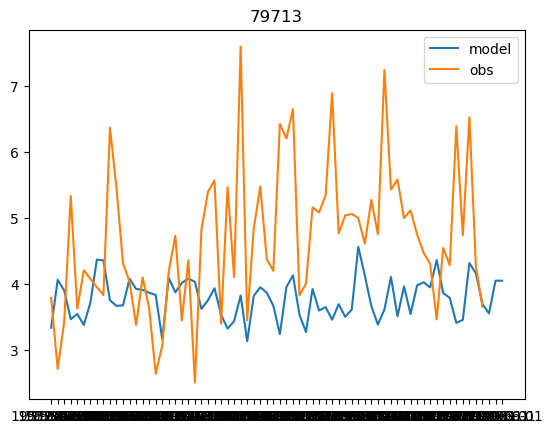

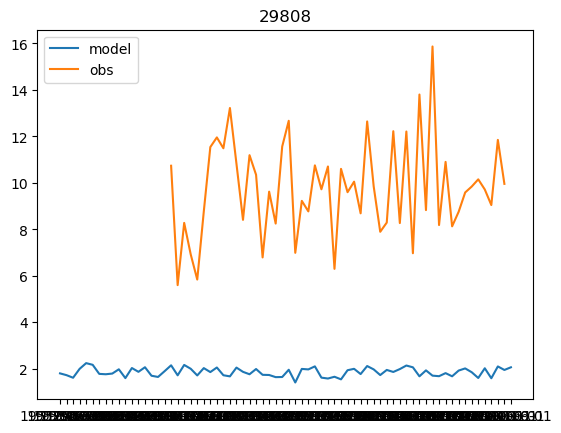

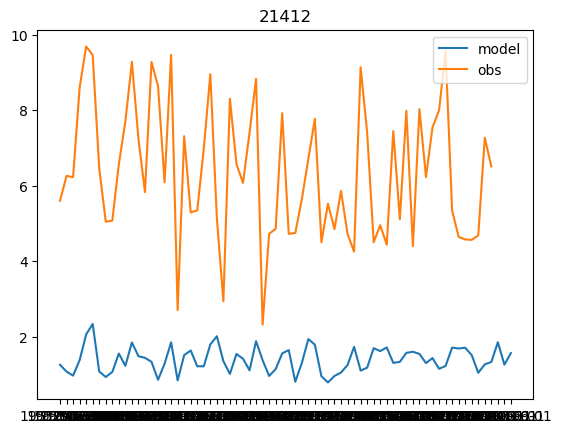

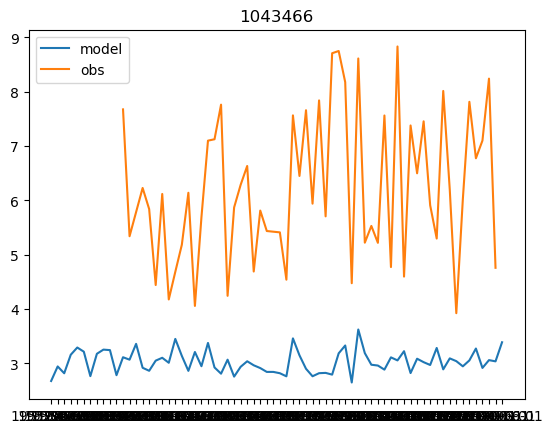

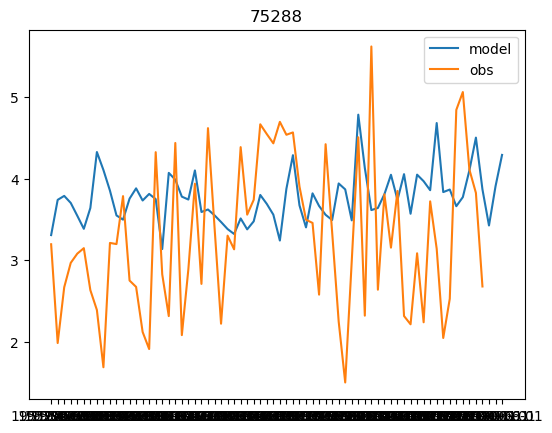

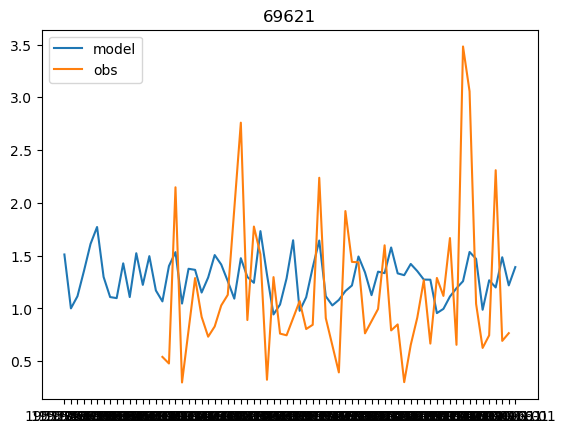

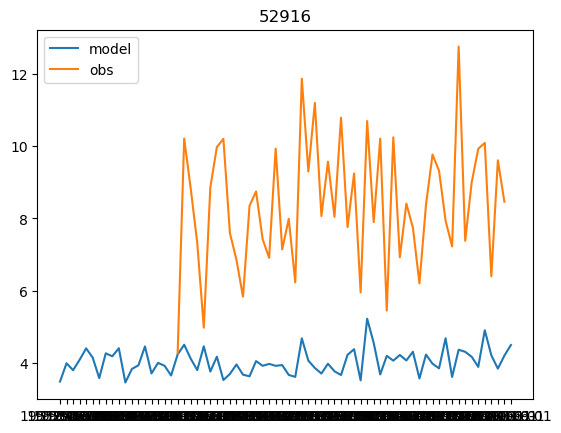

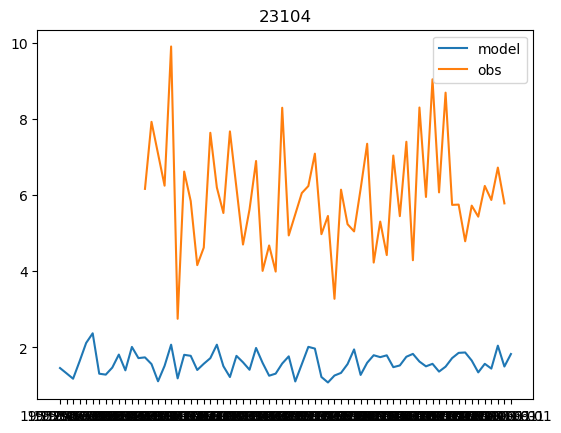

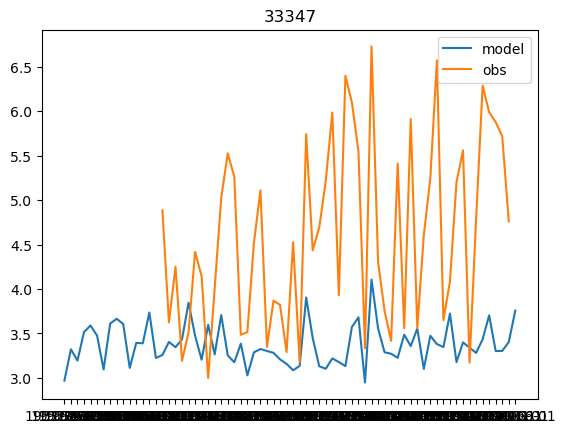

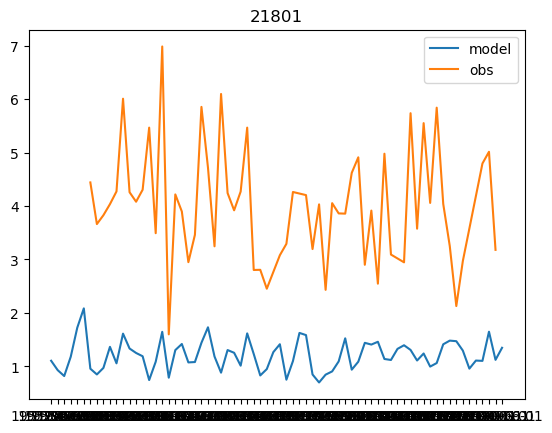

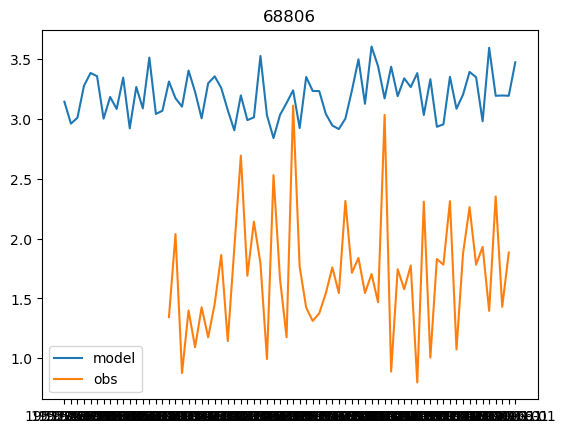

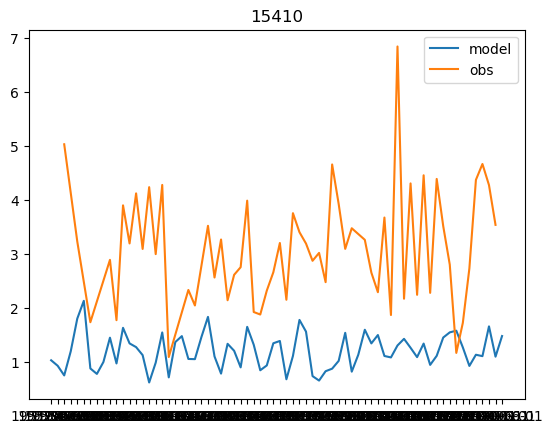

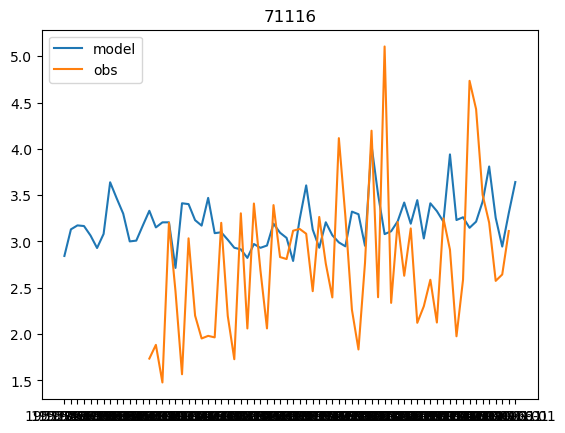

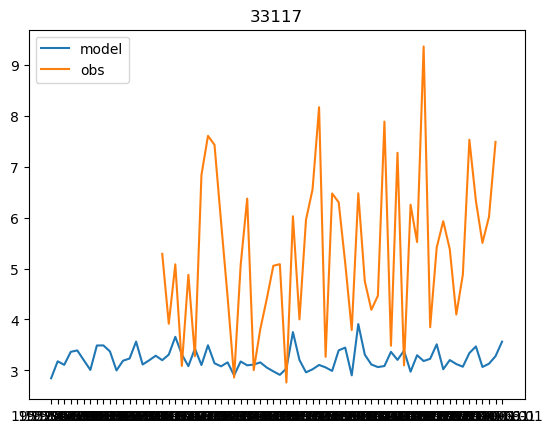

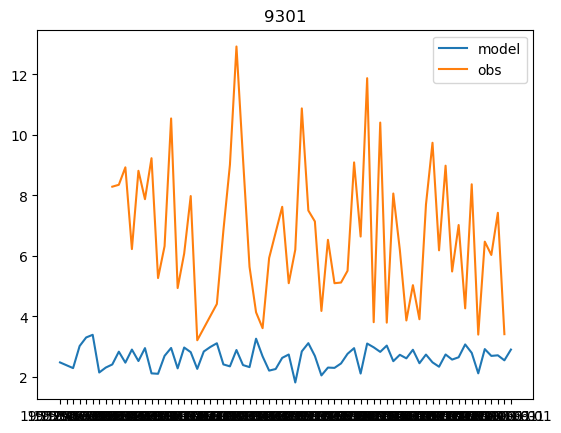

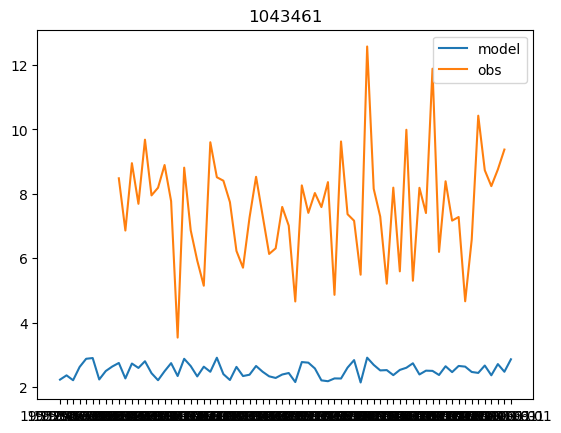

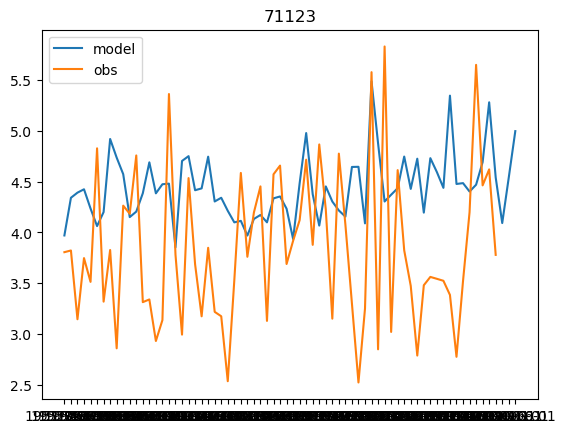

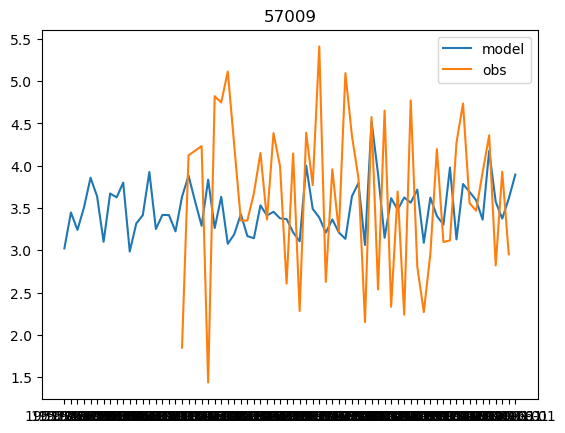

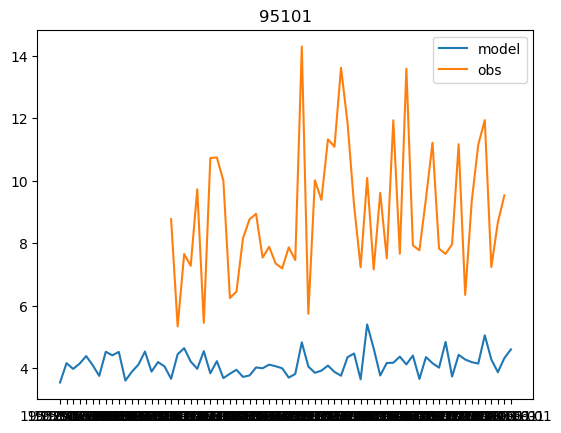

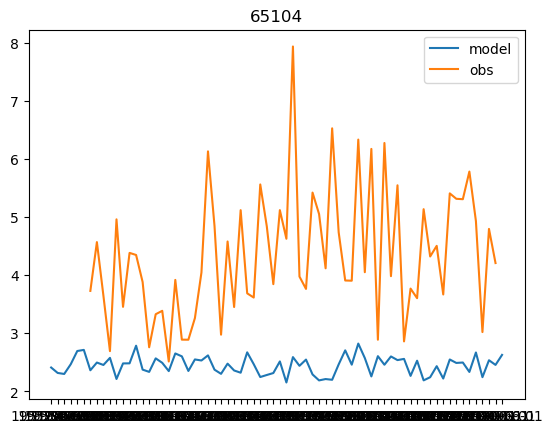

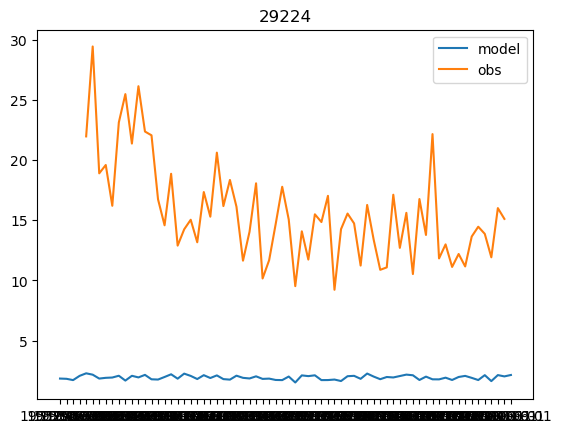

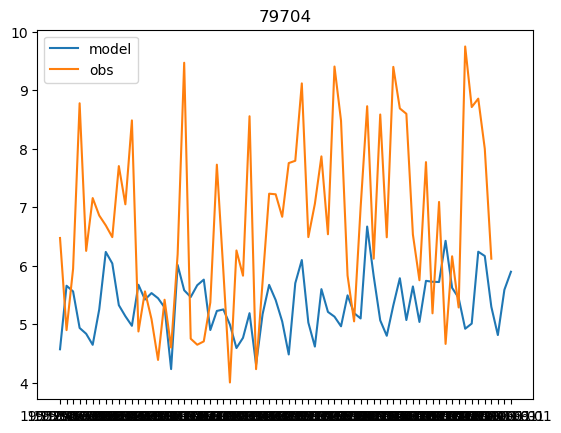

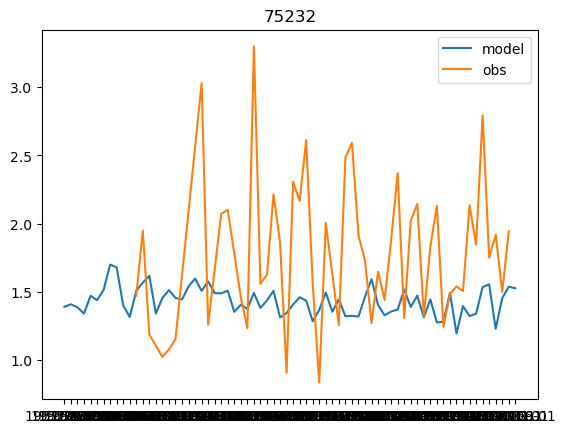

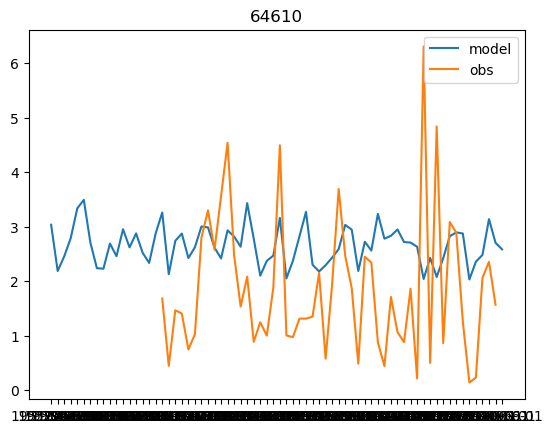

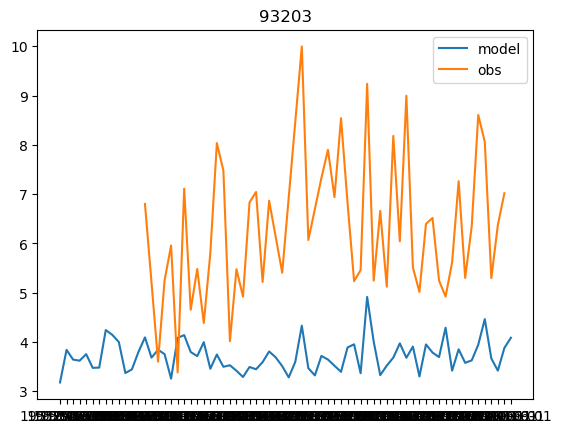

In [106]:
lats = []
lons = []
model_means = []
obs_means = []
errors = []
for site in winter_obs:

    model_ts = winter_model[site].dropna()
    obs_ts = winter_obs[site].dropna()
    
    model_means.append(model_ts.mean())
    obs_means.append(obs_ts.mean())
    
    errors.append(mae[site])
    
    lats.append((streamflow_meta_df.loc[int(site)]['centroid_lat']))
    lons.append(streamflow_meta_df.loc[int(site)]['centroid_lon'])
    
    if mae[site]>0:
        plt.plot(model_ts,label='model')
        plt.plot(obs_ts,label='obs')
        
        plt.legend()
        plt.title(site)

        plt.show()
        plt.close()


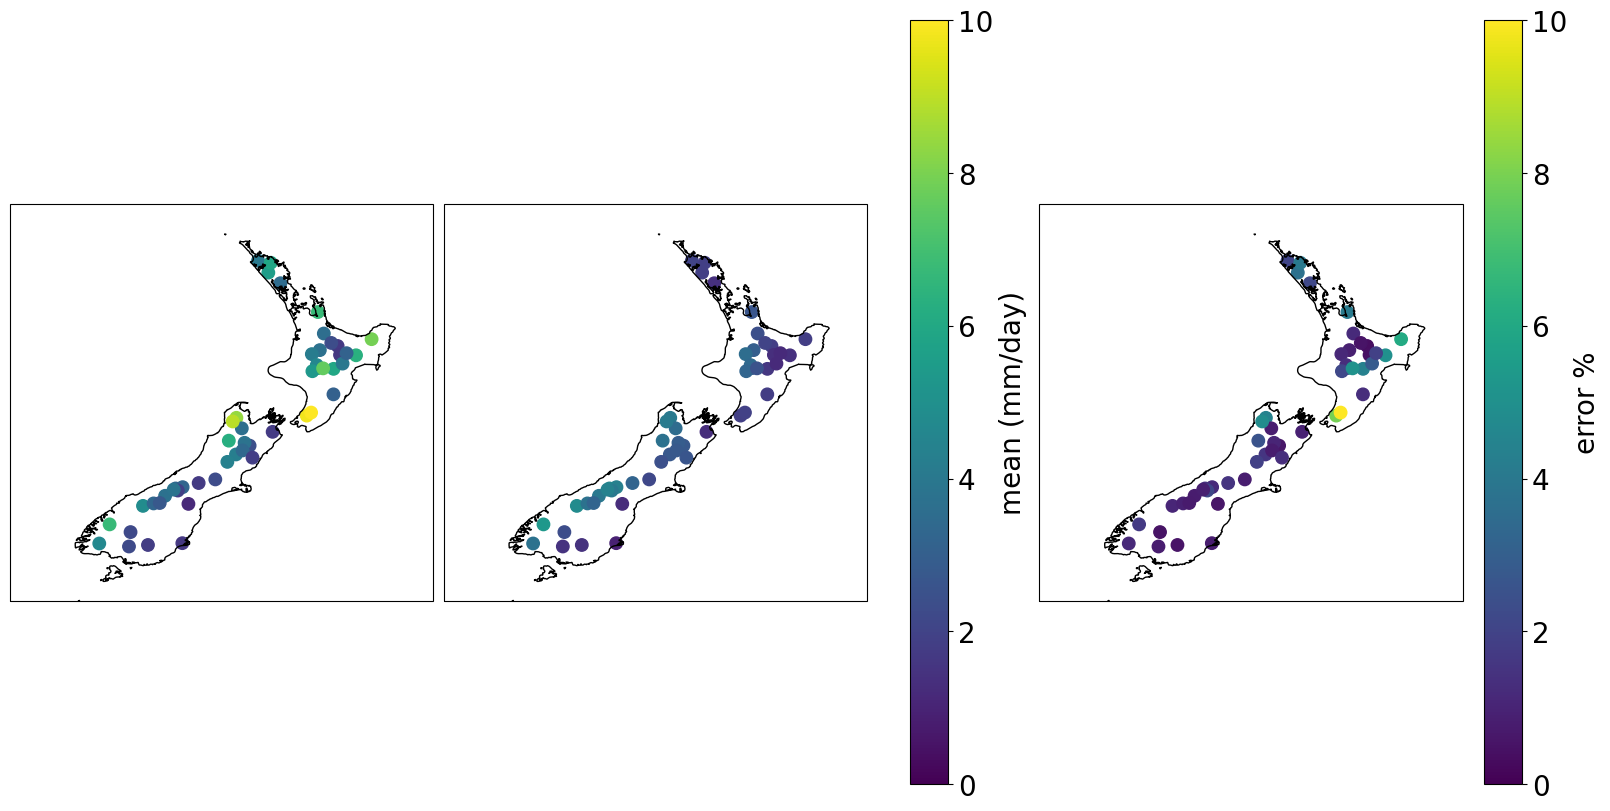

In [105]:
fig,axs = plt.subplots(1,3,figsize=(16,8),subplot_kw=dict(projection=ccrs.PlateCarree()),layout="constrained")

im = axs[0].scatter(lons,lats,c=obs_means,marker='o',s=80,vmin=0,vmax=10)
axs[1].scatter(lons,lats,c=model_means,marker='o',s=80,vmin=0,vmax=10)
er_im = axs[2].scatter(lons,lats,c=errors,marker='o',s=80,vmin=0,vmax=10)

for ax in axs.flatten():
    ax.coastlines()
    ax.add_feature(cf.BORDERS)
    ax.set_extent([164,180, -48,-33])#, crs=noproj)
        
cbar = fig.colorbar(im, ax=axs[0:2])
cbar.set_label(label='mean (mm/day)',size=20)
cbar.ax.tick_params(labelsize=20)

cbar = fig.colorbar(er_im, ax=axs[2])
cbar.set_label(label='error %',size=20)
cbar.ax.tick_params(labelsize=20)
